In [2]:
pip install tensorflow


  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached ml_dtypes-0.5.3-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.17.0-cp313-cp313-win_amd64.whl.metadata (34 kB)
Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl (332.0 MB)
   ---------------------------------------- 0.0/4.7 MB ? eta -:--:--
   -- -------

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [6]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0
x_train = np.expand_dims(x_train, -1) 
x_test  = np.expand_dims(x_test, -1)

print("Train shape:", x_train.shape, "Train labels:", y_train.shape)
print("Test shape: ", x_test.shape,  "Test labels: ", y_test.shape)


Train shape: (60000, 28, 28, 1) Train labels: (60000,)
Test shape:  (10000, 28, 28, 1) Test labels:  (10000,)


In [7]:
val_split = 0.1
val_count = int(len(x_train) * val_split)
x_val, y_val = x_train[:val_count], y_train[:val_count]
x_train2, y_train2 = x_train[val_count:], y_train[val_count:]

In [8]:
def build_cnn(input_shape=(28,28,1), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn()
model.summary()

C:\Users\shubh\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,370 (435.04 KB)

 Trainable params: 110,922 (433.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
checkpoint_dir = "checkpoints_mnist"
os.makedirs(checkpoint_dir, exist_ok=True)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, "mnist_cnn_best.h5"),
        save_best_only=True,
        monitor="val_accuracy",
        verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
]

In [11]:
history = model.fit(
    x_train2, y_train2,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=callbacks
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8305 - loss: 0.5872  
Epoch 1: val_accuracy improved from None to 0.28333, saving model to checkpoints_mnist\mnist_cnn_best.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.9316 - loss: 0.2493 - val_accuracy: 0.2833 - val_loss: 6.1006
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9831 - loss: 0.0585 
Epoch 2: val_accuracy improved from 0.28333 to 0.97717, saving model to checkpoints_mnist\mnist_cnn_best.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.9845 - loss: 0.0542 - val_accuracy: 0.9772 - val_loss: 0.0743
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9891 - loss: 0.0392 
Epoch 3: val_accuracy improved from 0.97717 to 0.98283, saving model to checkpoints_mnist\mnist_cnn_best.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9889 - loss: 0.0381 - val_accuracy: 0.9828 - val_loss: 0.0529
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9913 - loss: 0.0302 
Epoch 4: val_accuracy did not improve from 0.98283
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.9911 - loss: 0.0294 - val_accuracy: 0.9807 - val_loss: 0.0627
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9931 - loss: 0.0244  
Epoch 5: val_accuracy did not improve from 0.98283
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 92ms/step - accuracy: 0.9931 - loss: 0.0235 - val_accuracy: 0.9733 - val_loss: 0.0925
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9941 - loss: 0.0191 
Epoch 6: val_accuracy improved from 0.98283 to 0.98417, saving model to checkpoints_mnist\mnist_cnn_best.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.9937 - loss: 0.0201 - val_accuracy: 0.9842 - val_loss: 0.0485
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9962 - loss: 0.0144 
Epoch 7: val_accuracy did not improve from 0.98417
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 90ms/step - accuracy: 0.9952 - loss: 0.0165 - val_accuracy: 0.9610 - val_loss: 0.1350
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9964 - loss: 0.0124 
Epoch 8: val_accuracy improved from 0.98417 to 0.98883, saving model to checkpoints_mnist\mnist_cnn_best.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 87ms/step - accuracy: 0.9963 - loss: 0.0129 - val_accuracy: 0.9888 - val_loss: 0.0381
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9970 - loss: 0.0101 
Epoch 9: val_accuracy improved from 0.98883 to 0.99000, saving model to checkpoints_mnist\mnist_cnn_best.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.9967 - loss: 0.0108 - val_accuracy: 0.9900 - val_loss: 0.0341
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9969 - loss: 0.0091 
Epoch 10: val_accuracy did not improve from 0.99000
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 75ms/step - accuracy: 0.9963 - loss: 0.0110 - val_accuracy: 0.9887 - val_loss: 0.0376
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9967 - loss: 0.0102 
Epoch 11: val_accuracy did not improve from 0.99000
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 84ms/step - accuracy: 0.9971 - loss: 0.0094 - val_accuracy: 0.9875 - val_loss: 0.0458
Epoch 12/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9969 - loss: 0.0093 
Epoch 12: val_accuracy improved from 0.99000 to 0.99050, saving model to checkpoints_mnist\mnist_cnn_best.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 78ms/step - accuracy: 0.9968 - loss: 0.0098 - val_accuracy: 0.9905 - val_loss: 0.0318
Epoch 13/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9979 - loss: 0.0061 
Epoch 13: val_accuracy did not improve from 0.99050
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 84ms/step - accuracy: 0.9975 - loss: 0.0078 - val_accuracy: 0.9878 - val_loss: 0.0422
Epoch 14/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9976 - loss: 0.0073 
Epoch 14: val_accuracy did not improve from 0.99050
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - accuracy: 0.9973 - loss: 0.0086 - val_accuracy: 0.9905 - val_loss: 0.0333
Epoch 15/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9976 - loss: 0.0062 
Epoch 15: val_accuracy improved from 0.99050 to 0.99100, saving model to checkpoints_mnist\mnist_cnn_best.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.9977 - loss: 0.0065 - val_accuracy: 0.9910 - val_loss: 0.0335
Epoch 16/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9985 - loss: 0.0054 
Epoch 16: val_accuracy did not improve from 0.99100
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 85ms/step - accuracy: 0.9986 - loss: 0.0051 - val_accuracy: 0.9865 - val_loss: 0.0536
Epoch 17/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9978 - loss: 0.0055 
Epoch 17: val_accuracy did not improve from 0.99100
422/422 ━━━━━━━━━━━━━━━━━━━━ 48s 113ms/step - accuracy: 0.9979 - loss: 0.0056 - val_accuracy: 0.9893 - val_loss: 0.0383
Epoch 18/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9977 - loss: 0.0073 
Epoch 18: val_accuracy did not improve from 0.99100
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 124ms/step - accuracy: 0.9977 - loss: 0.0074 - val_accuracy: 0.9878 - val_loss: 0.0437


In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

313/313 - 4s - 14ms/step - accuracy: 0.9928 - loss: 0.0289

Test accuracy: 0.9928, Test loss: 0.0289


In [13]:
model.save("mnist_cnn_final.h5")
print("Saved model to mnist_cnn_final.h5")

Saved model to mnist_cnn_final.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step


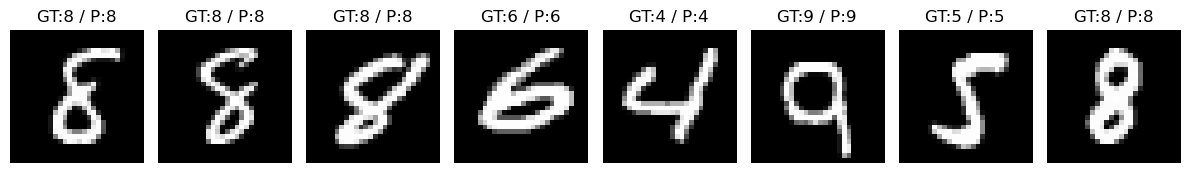

In [14]:
num_samples = 8
indices = np.random.choice(len(x_test), num_samples, replace=False)
samples = x_test[indices]
labels  = y_test[indices]
preds = np.argmax(model.predict(samples), axis=1)

plt.figure(figsize=(12,3))
for i in range(num_samples):
    plt.subplot(1, num_samples, i+1)
    plt.imshow(samples[i].squeeze(), cmap='gray')
    plt.title(f"GT:{labels[i]} / P:{preds[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()